<a href="https://colab.research.google.com/github/DataAnalystSergio/Student-performance-prediction/blob/main/TP1/EJERCICIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Integrante:
* SERGIO CARLO ARMIJO CARRILLO

# Rendimiento estudiantil

Este dataset es un conjunto de datos diseñado para examinar los factores que influyen en el rendimiento académico de los estudiantes. El dataset consta de 10,000 registros de estudiantes, y cada registro contiene información sobre varios predictores y un índice de rendimiento.

Variables:

* **Hours Studied:** El número total de horas que cada estudiante ha dedicado al estudio.
* **Previous Scores:** Los puntajes obtenidos por los estudiantes en pruebas anteriores.
* **Extracurricular Activities:** Indica si el estudiante participa en actividades extracurriculares (Sí o No).
* **Sleep Hour:** El promedio de horas de sueño por día de cada estudiante.
* **Sample Question Papers Practiced:** El número de exámenes de muestra que el estudiante practicó.

Variable Objetivo:

* **Performance Index:** Una medida del rendimiento académico total de cada estudiante. El índice de rendimiento ha sido redondeado al número entero más cercano y varía de 10 a 100, donde los valores más altos indican un mejor rendimiento.

El objetivo de este dataset es proporcionar información sobre la relación entre las variables predictoras y el índice de rendimiento. Investigadores y analistas de datos pueden usar este dataset para explorar el impacto de las horas de estudio, los puntajes previos, las actividades extracurriculares, las horas de sueño y los exámenes de prueba en el rendimiento de los estudiantes.

## Por Resolver:

1. Exploratory Data Analysis (EDA)
  * Determinar las dimensiones del dataset para entender su estructura.
  * Identificar si existen valores faltantes en las variables y su magnitud.
  * Evaluar el rango de los valores de cada variable para obtener un panorama general de los datos.
  * Analizar la distribución de la variable objetivo (Performance Index) para ver si sigue una distribución normal u otra forma.
  * Explorar las correlaciones entre las variables predictoras y el Performance Index para identificar relaciones significativas.
  * Examinar la relación entre las variables numéricas, como "Hours Studied" y "Performance Index", para obtener posibles tendencias.
  * Evaluar el impacto de la participación en actividades extracurriculares sobre el Performance Index.
  * Identificar las características comunes de los estudiantes con puntajes altos y bajos en el Performance Index.
2. Limpieza y preparación de datos
  * Determinar si existen valores atípicos en las variables numéricas que deban ser tratados.
  * Decidir el tratamiento adecuado para variables categóricas como "Extracurricular Activities" (por ejemplo, conversión a variables dummy).
  * Evaluar si es necesario normalizar o estandarizar las variables numéricas para mejorar el rendimiento del modelo.
3. Selección de características
  * Identificar las variables con mayor correlación con el Performance Index que deben ser incluidas en el modelo.
  * Decidir si se deben eliminar variables con baja correlación o aquellas que no aporten información relevante para el modelo.
4. Modelado (Regresiones lineales o polinómicas)
  * Comenzar con una regresión lineal simple usando "Hours Studied" como predictor principal para evaluar su impacto en el Performance Index.
  * Incluir más variables predictoras en la regresión lineal múltiple y observar los resultados.
  * Experimentar con una regresión polinómica para evaluar si un modelo no lineal mejora el ajuste.
  * Utiliza Statsmodels y Scikit-learn para realizar las regresiones.
5. Evaluación del modelo
  * Medir el rendimiento del modelo utilizando métricas como R² y RMSE para evaluar la calidad del ajuste.
  * Comparar los resultados obtenidos de la regresión polinómica frente a la lineal para ver si hay una mejora significativa.
  * Analizar el comportamiento de los residuos del modelo para verificar si se distribuyen aleatoriamente, indicando un buen ajuste.
6. Interpretación de resultados
  * Interpretar los coeficientes de las variables del modelo para entender el impacto de cada predictor en el Performance Index.
  * Identificar los predictores con mayor impacto en el rendimiento académico de los estudiantes.
  * Evaluar si algunos factores no tienen un impacto claro en el rendimiento académico.
  * Resumir las principales conclusiones obtenidas del análisis del dataset.

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PAE SERGY/CLASES/7 Y 8/1_REGRESION/data/Student_Performance.csv')

In [ ]:
print(df)

      Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0                 7               99                        Yes            9   
1                 4               82                         No            4   
2                 8               51                        Yes            7   
3                 5               52                        Yes            5   
4                 7               75                         No            8   
...             ...              ...                        ...          ...   
9995              1               49                        Yes            4   
9996              7               64                        Yes            8   
9997              6               83                        Yes            8   
9998              9               97                        Yes            7   
9999              7               74                         No            8   

      Sample Question Papers Practiced 

# **1. EXPLORATORY DATA ANALYSIS (EDA)**

**Dimensiones del Dataset**

In [ ]:
df.shape

(10000, 6)

Nuestra data está conformada por 10000 registros (filas) x 6 columnas.

**Identificar Valores Faltantes**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


No existen valores faltantes.

**Panorama General de los Datos**

In [ ]:
df.describe(include = 'all')

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


**Hours Studied:** La mayoría estudia entre 3 y 7 horas, con un promedio de 5, hay una dispersión moderada; algunos estudian poco y otros mucho.

**Previous Scores:** Hay estudiantes con rendimientos muy diferentes; no todos parten del mismo nivel.

**Extracurricular Activities:** La mayoría no participa en actividades extracurriculares (~50.5 %).

**Sleep Hours:** El descanso promedio es adecuado, aunque algunos duermen menos de lo recomendado.

**Sample Question Papers Practiced:** Hay estudiantes que no practican nada y otros que practican mucho; el promedio ronda 4–5 cuestionarios.

**Performance Index:** El desempeño promedio es medio (55 sobre 100), con una dispersión alta — algunos destacan mucho y otros rinden bajo.

**Distribución de la variable Objetivo (Performance Index)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")
%matplotlib inline
import numpy as np

# Calculamos el Nº de bins optimo para nuestra grafica.
q25, q75 = np.percentile(df['Performance Index'], [25, 75])
iqr = q75 - q25
bin_width = 2 * iqr * (len(df['Performance Index']) ** (-1/3))
bins = int((df['Performance Index'].max() - df['Performance Index'].min()) / bin_width)
print("Número óptimo de bins:", bins)

Número óptimo de bins: 31


<Figure size 2000x1000 with 0 Axes>

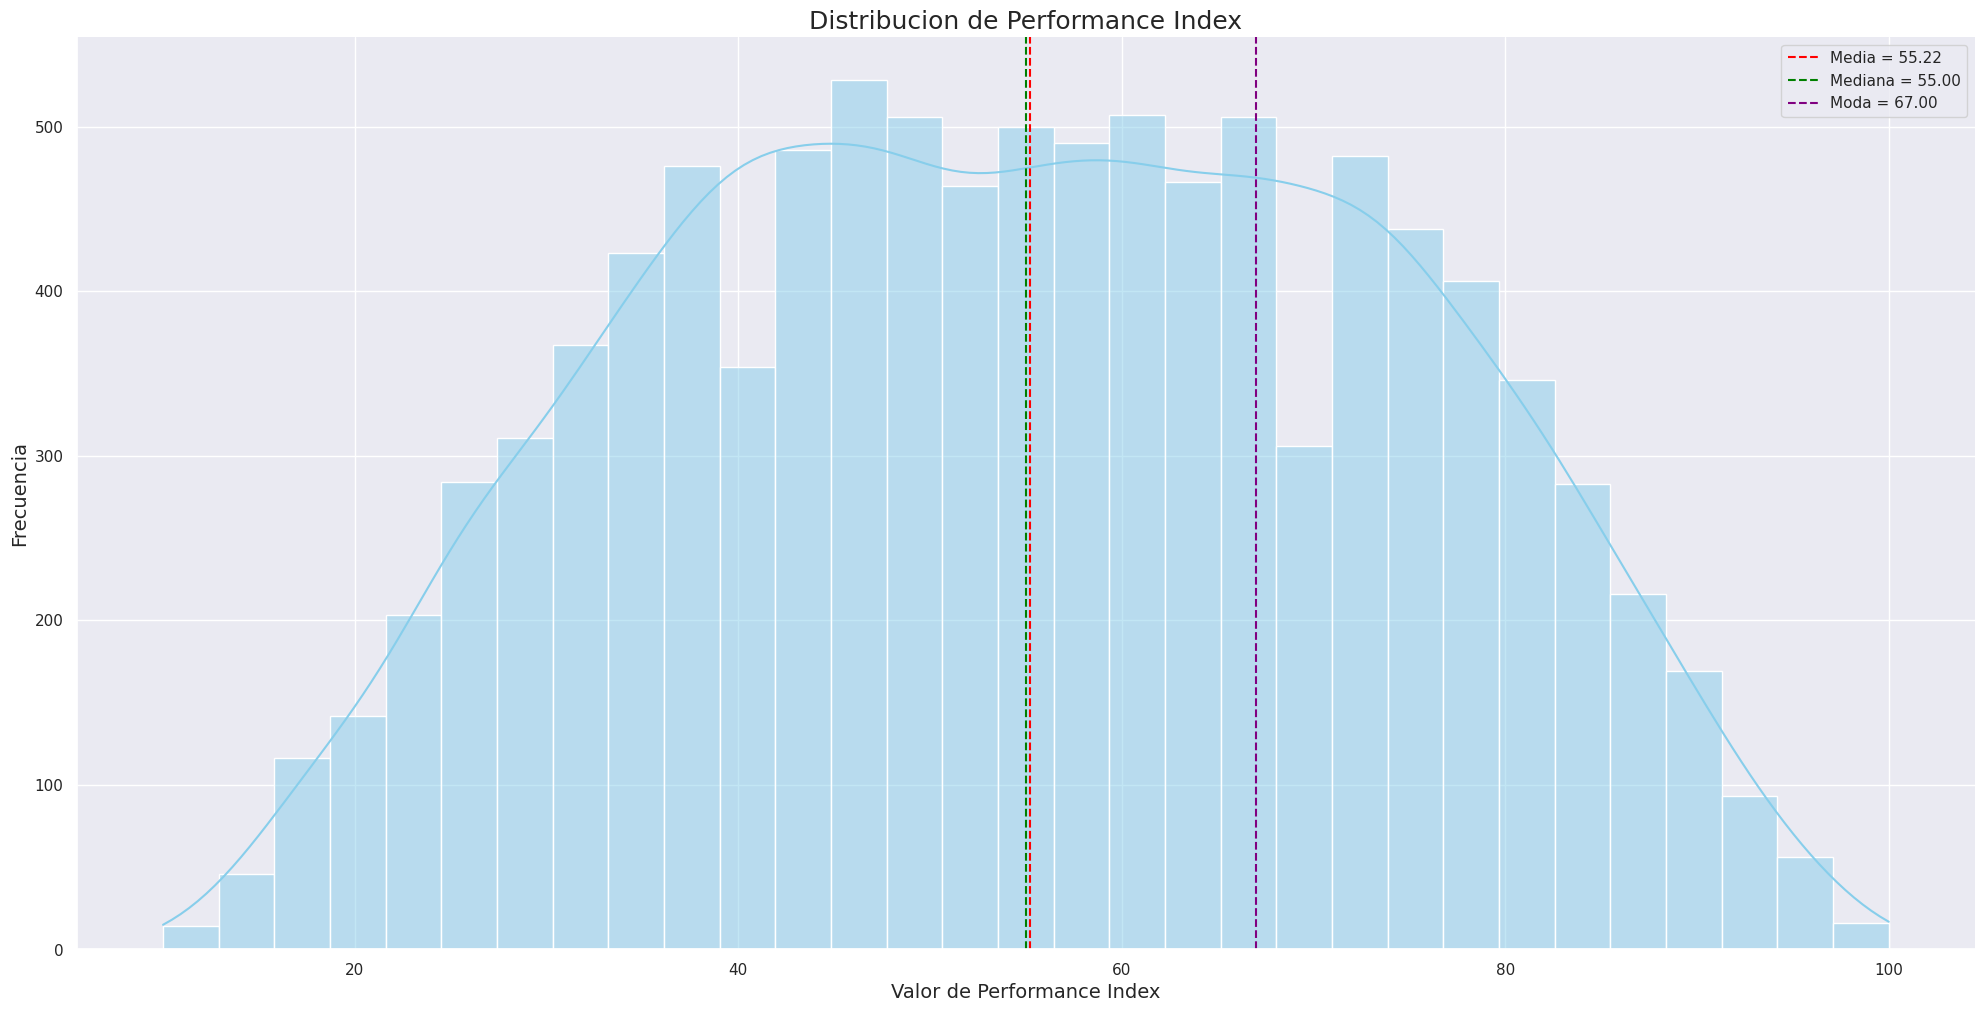

In [ ]:
# Calculamos la media, mediana y moda para representarlo visualmente y realizar una mejor interpretacion.
media = df['Performance Index'].mean()
mediana = df['Performance Index'].median()
moda = df['Performance Index'].mode()[0]

# Graficamos nuestra variable "Performance Index"
plt.figure(figsize=(20,10))
sns.displot(df['Performance Index'], kde=True, bins=31, color='skyblue', height=10, aspect=2)
plt.axvline(media, color='red', linestyle='--', label=f'Media = {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana = {mediana:.2f}')
plt.axvline(moda, color='purple', linestyle='--', label=f'Moda = {moda:.2f}')
plt.title('Distribucion de Performance Index', fontsize=18)
plt.xlabel('Valor de Performance Index', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.legend()
plt.show()

Coeficiente de asimetria (Skewness)

In [ ]:
df['Performance Index'].skew()

np.float64(-0.0017400273072201125)

Test de Shapiro-Wilk

In [ ]:
from scipy.stats import shapiro

# Tomamos una muestra de 5000 valores para evitar error por tamaño
stat, p = shapiro(df['Performance Index'].sample(5000, random_state=42))

print(f"Estadístico Shapiro-Wilk: {stat:.4f}")
print(f"P-valor: {p:.4f}")

if p > 0.05:
    print("✅ La distribución es aproximadamente normal.")
else:
    print("❌ La distribución no es normal.")


Estadístico Shapiro-Wilk: 0.9849
P-valor: 0.0000
❌ La distribución no es normal.


**Conclucion General:**

La distribucion de nuestra variable no es perfectamente normal, muestra un ligero sesgo asimetrico negativo.

Esto quiere decir, que la mayoria de los estudiantes presentan un alto rendimiento (Performance Index), solo una pequeña minoria presentan niveles bajos.

**Concluciones Especificas:**

Al obtener una moda (67) mayor que la media (55.22) y la mediana (55), indica que la mayoria de los estudiantes presenten un alto rendimiento por encima del promedio.

El rendimiento en el histograma y la curva KDE muestra un unico pico (unimodal) en la zona alta.

El **Coeficiente de Skewness** revela la precencia de un pequeño grupo de estudiantes con bajo nivel de rendimiento, por debajo del promedio.

El **test normalidad** (Shapiro, p value) determinan que los desempeños de los estudiantes presentan cierta estabilidad y homogeneidad.

**Correlacion entre las variables predictoras y el Performance Index**

In [ ]:
corr = df.corr(numeric_only=True)
corr['Performance Index'].sort_values(ascending=False)

,Performance Index
Performance Index,1.000000
Previous Scores,0.915189
Hours Studied,0.373730
Sleep Hours,0.048106
Sample Question Papers Practiced,0.043268


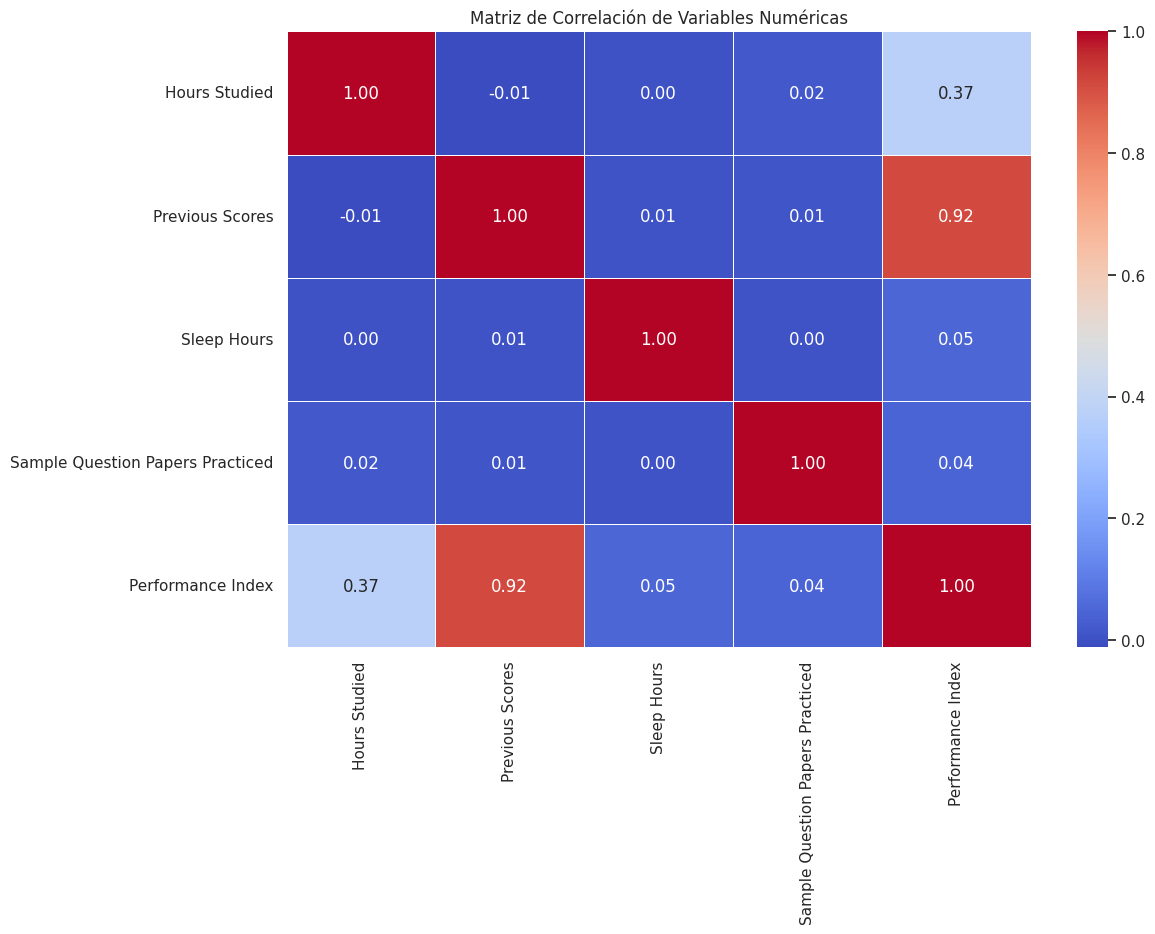

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Relacion entre las Variables numericas y Performance Index**

In [ ]:
# Utilizamos Pearson para identificar cuales variables se correlacionan significativamente.
from scipy.stats import pearsonr

for col in df.columns:
    if col != 'Performance Index' and df[col].dtype in ['float64', 'int64']:
        r, p = pearsonr(df[col], df['Performance Index'])
        print(f'{col}: r = {r:.3f}, p = {p:.4f}')

Hours Studied: r = 0.374, p = 0.0000
Previous Scores: r = 0.915, p = 0.0000
Sleep Hours: r = 0.048, p = 0.0000
Sample Question Papers Practiced: r = 0.043, p = 0.0000


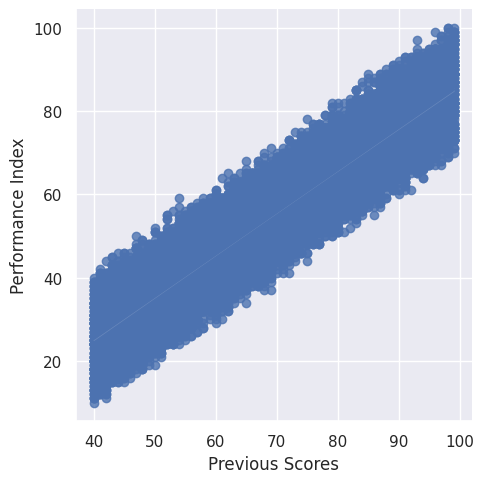

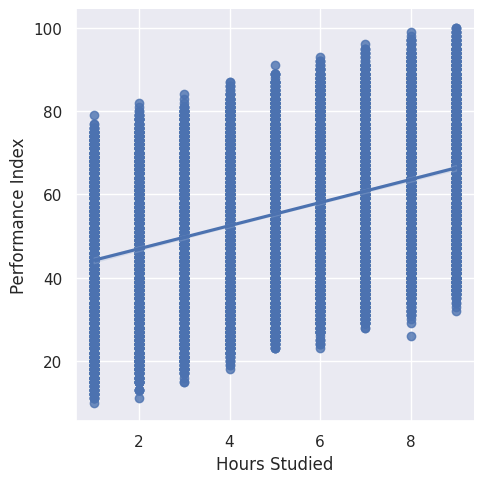

In [ ]:
# Complementamos el analisis con un Grafico de Dispersion para visualizar las variables que tengan mayor relacion con nuestra target.
sns.lmplot(x='Previous Scores', y='Performance Index', data=df)
sns.lmplot(x='Hours Studied', y='Performance Index', data=df)

**Conclucion:**

En base a los analisis realizados, encontramos que el Previous Scores es el factor predictivo mas dominante y fiable del Performance Index.

Conociendo el puntaje previo de un estudiante, se puede predecir su rendimiento actual con un alto grado de precisión.

Estudiar más horas tiene un impacto positivo demostrable en el rendimiento. Sin embargo, por sí solo, no es un predictor fiable debido a la alta variabilidad en los resultados.

Las demas variables no influyen significativamente al Performance Index.

**Impacto de la participación en actividades extracurriculares sobre el Performance Index**

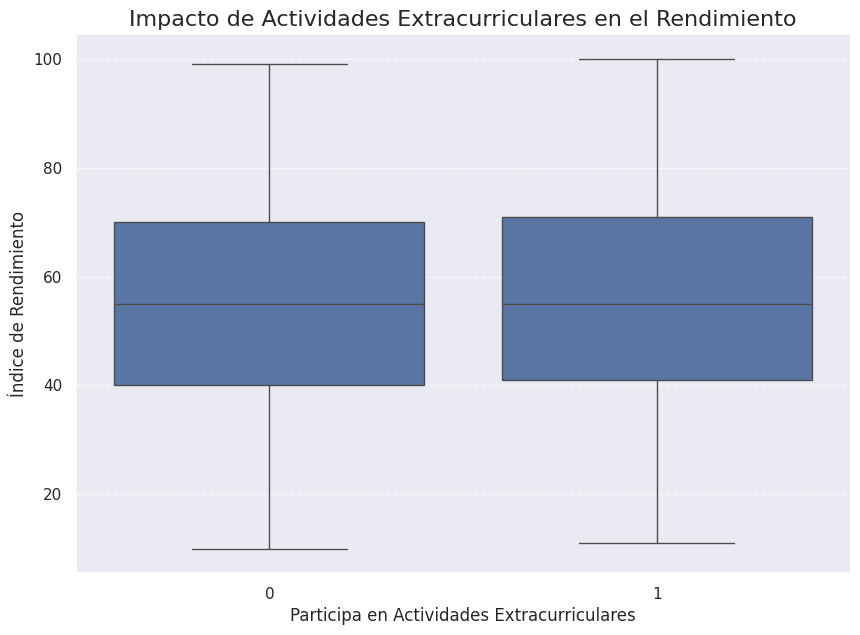

In [ ]:
# Utilizaremos un Gráfico de Cajas (Box Plot)

# Convertimos nuestra variable categorica a numerica con una transformacion.
df['Actividades_Num']= df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(10, 7))
sns.boxplot(x='Actividades_Num', y='Performance Index', data=df)

# Añadir títulos y etiquetas claras
plt.title('Impacto de Actividades Extracurriculares en el Rendimiento', fontsize=16)
plt.xlabel('Participa en Actividades Extracurriculares', fontsize=12)
plt.ylabel('Índice de Rendimiento', fontsize=12)
# Asegúramos que las etiquetas del eje x sean descriptivas
plt.xticks(ticks=[0, 1], labels=[0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Analisis numerico y prueba ( T-test)

Comparamos estadisticamente el nivel de significancia  entre los promedios de los grupos (agrupamos y Calculamos las Medias).

In [ ]:
# Agrupar por la columna y calcular la media del Performance Index
mean_performance = df.groupby('Actividades_Num')['Performance Index'].mean()
print("Rendimiento promedio por grupo:")
print(mean_performance)

Rendimiento promedio por grupo:
Actividades_Num
0    54.758511
1    55.700889
Name: Performance Index, dtype: float64


In [ ]:
# Realizamos la prueba T
from scipy.stats import ttest_ind

# Separar el Performance Index en dos grupos
grupo_No = df[df['Actividades_Num'] == 0]['Performance Index']
grupo_Yes = df[df['Actividades_Num'] == 1]['Performance Index']

# Realizar la prueba T para muestras independientes
t_stat, p_value = ttest_ind(grupo_Yes, grupo_No)

print(f"\nEstadístico T: {t_stat:.4f}")
print(f"P-valor: {p_value:.4f}")

# Interpretar el p-valor
if p_value < 0.05:
    print("\n🎯 Conclusión: La diferencia es estadísticamente significativa.")
    print("Rechazamos la hipótesis nula. La participación en actividades extracurriculares tiene un impacto en el rendimiento.")
else:
    print("\nConclusion: La diferencia NO es estadísticamente significativa.")
    print("No podemos rechazar la hipótesis nula. La diferencia observada podría deberse al azar.")


Estadístico T: 2.4530
P-valor: 0.0142

🎯 Conclusión: La diferencia es estadísticamente significativa.
Rechazamos la hipótesis nula. La participación en actividades extracurriculares tiene un impacto en el rendimiento.


**Características comunes de los estudiantes con puntajes altos y bajos en el Performance Index**

En base al analisis obtenemos que:

Los **estudiantes con un alto** 'Performance Index' se caracterizan por una **combinación de conocimiento previo sólido y dedicación al estudio.**

Los **estudiantes con un bajo** 'Performance Index' se caracterizan por lo opuesto: tienden a tener **bajos puntajes previos y estudiar menos horas.**

# 2. LIMPIEZA DE DATOS

**Tratamiento de valores atípicos en las variables numéricas**

Metodo de deteccion de valores atipicos univariantes ( RANGO INTERCUARTILICO (IQR))

In [ ]:
# 1. Definimos las variables numéricas a analizar
variables_numericas = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']

print("--- Detección Univariante por IQR ---")

for col in variables_numericas:
    # 2. Calcular Q1, Q3 e IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 3. Calcular los límites (cercas)
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # 4. Identificar los atípicos
    atípicos = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    # 5. Reportar los resultados
    num_atípicos = len(atípicos)
    porcentaje_atípicos = (num_atípicos / len(df)) * 100

    print(f"\nVariable: {col}")
    print(f"  IQR (Q3-Q1): {IQR:.2f}")
    print(f"  Límites: [{limite_inferior:.2f}, {limite_superior:.2f}]")
    print(f"  Total de Atípicos detectados: {num_atípicos}")
    print(f"  Porcentaje del Dataset: {porcentaje_atípicos:.2f}%")

--- Detección Univariante por IQR ---

Variable: Hours Studied
  IQR (Q3-Q1): 4.00
  Límites: [-3.00, 13.00]
  Total de Atípicos detectados: 0
  Porcentaje del Dataset: 0.00%

Variable: Previous Scores
  IQR (Q3-Q1): 31.00
  Límites: [7.50, 131.50]
  Total de Atípicos detectados: 0
  Porcentaje del Dataset: 0.00%

Variable: Sleep Hours
  IQR (Q3-Q1): 3.00
  Límites: [0.50, 12.50]
  Total de Atípicos detectados: 0
  Porcentaje del Dataset: 0.00%

Variable: Sample Question Papers Practiced
  IQR (Q3-Q1): 5.00
  Límites: [-5.50, 14.50]
  Total de Atípicos detectados: 0
  Porcentaje del Dataset: 0.00%

Variable: Performance Index
  IQR (Q3-Q1): 31.00
  Límites: [-6.50, 117.50]
  Total de Atípicos detectados: 0
  Porcentaje del Dataset: 0.00%


Visualizacion con Boxplot(Grafico de caja)

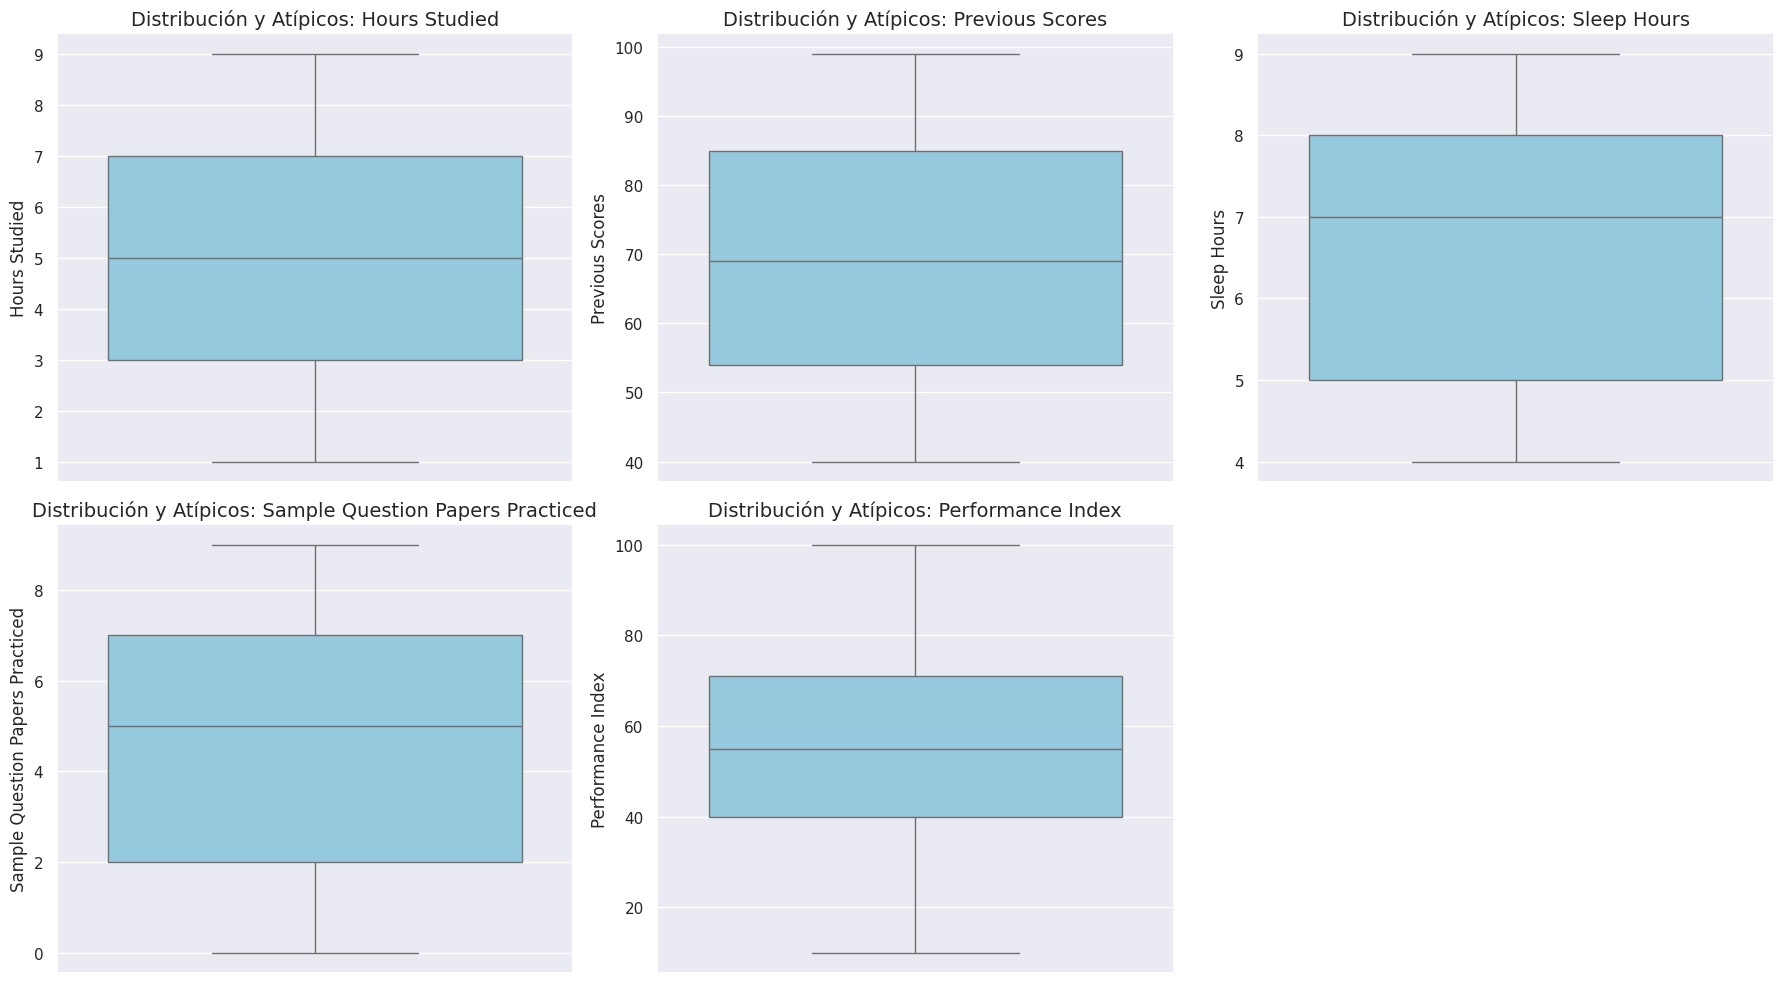

In [ ]:
# Lista de las variables numéricas para el boxplot
variables_numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

# 1. Configuramos la figura para tener múltiples gráficos (subplots)
# Usaremos una configuración de 2 filas y 3 columnas, dejando una vacía al final.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

# Aplanar el array de axes para fácil iteración
axes = axes.flatten()

# 2. Iterar sobre cada variable y dibujar su boxplot
for i, col in enumerate(variables_numericas):
    # Usamos sns.boxplot para dibujar el gráfico en el eje (axis) correspondiente
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución y Atípicos: {col}', fontsize=14)
    axes[i].set_ylabel(col, fontsize=12)

# 3. Eliminar el subgráfico extra (el que está vacío en la posición 5)
fig.delaxes(axes[5])

# 4. Ajustar el layout para evitar solapamiento de títulos y etiquetas
plt.tight_layout()

# 5. Mostrar la figura
plt.show()

**Conclucion:** Encontramos que al determinar el IQR y graficar los Boxplot, no se obtienen valores atipicos que esten alejados del 50% de los datos.

**Tratamiento para la Variable: Extracurricular Activities**

Para nuestro caso, la variable "Extracurricular Activities" presenta 2 categorias (Si/No) codificacion Binaria.

Por ende el metodo mas adecuado es la Codificacion Binaria (variable Dummy).
Este tratamiento ya lo hemos realizado en analisis anteriores.

In [ ]:
df['Actividades_Num'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

**Evaluar la Transformacion: Normalizacion y Estandarizacion**

Analizaremos la distribución nuestras variables y determinar que transformación es el más adecuado dado que hemos utilizado una prueba de T (T-Test).

Pasos:

1. Evalúar la Normalidad: Con gráficos Q-Q plots e histogramas para las variables numéricas.

2. Si son normales: Aplicamos Estandarización.

3. Si están fuertemente sesgadas: Consideramos una Transformación Logarítmica (para intentar la normalidad) y luego la Estandarización sobre el resultado logarítmico.

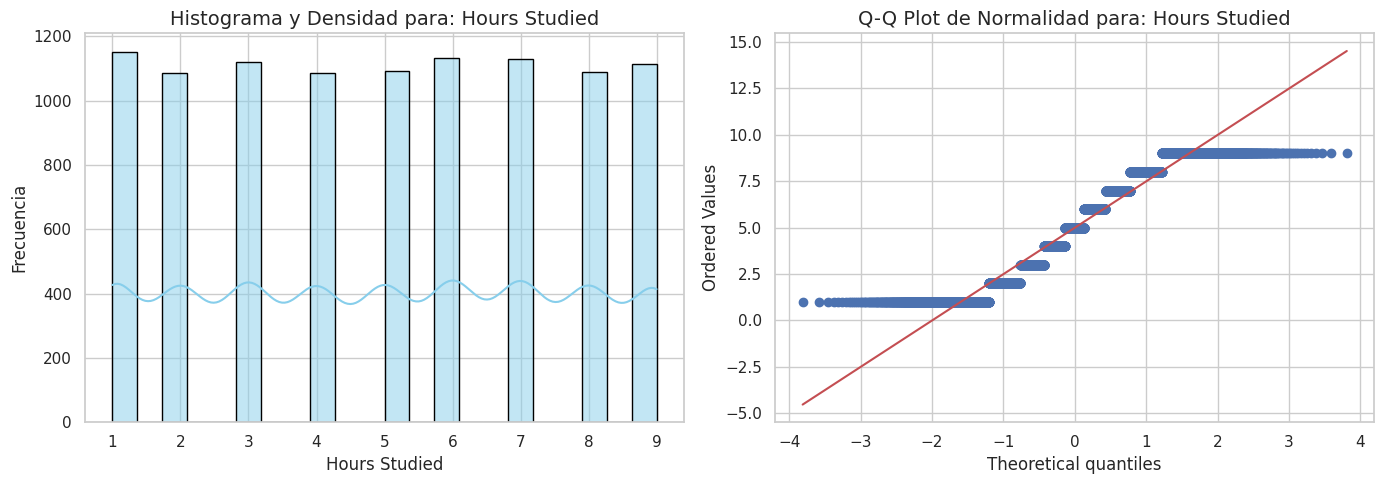

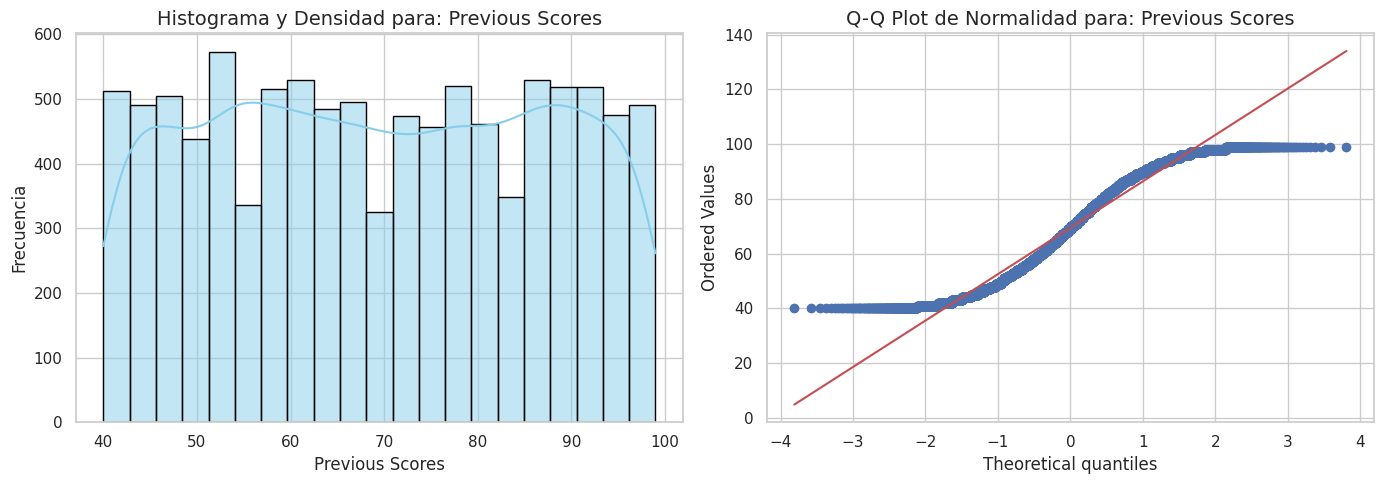

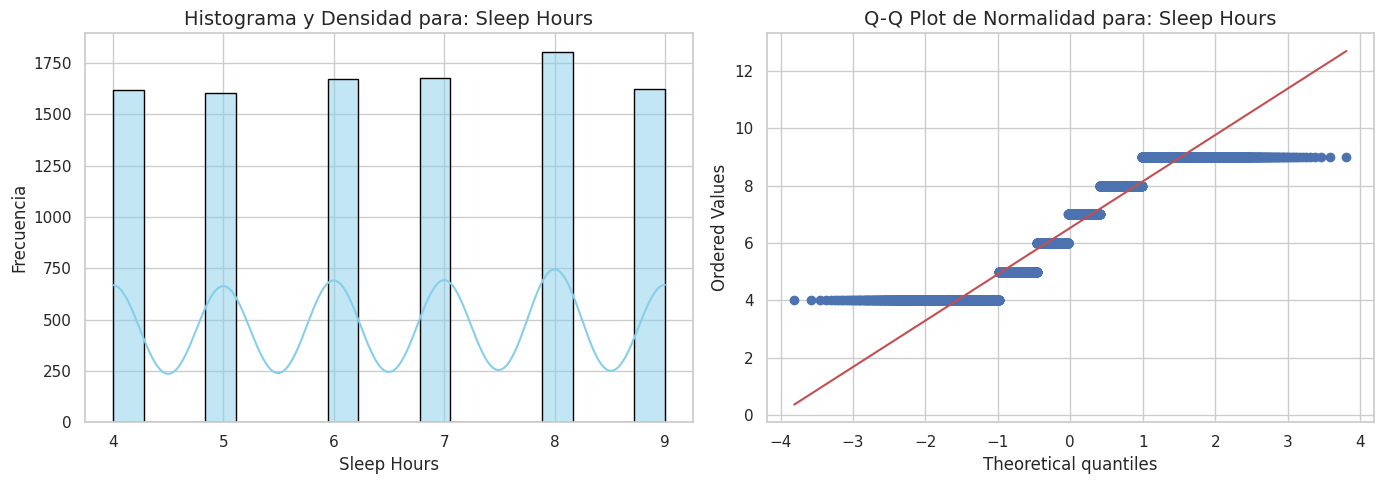

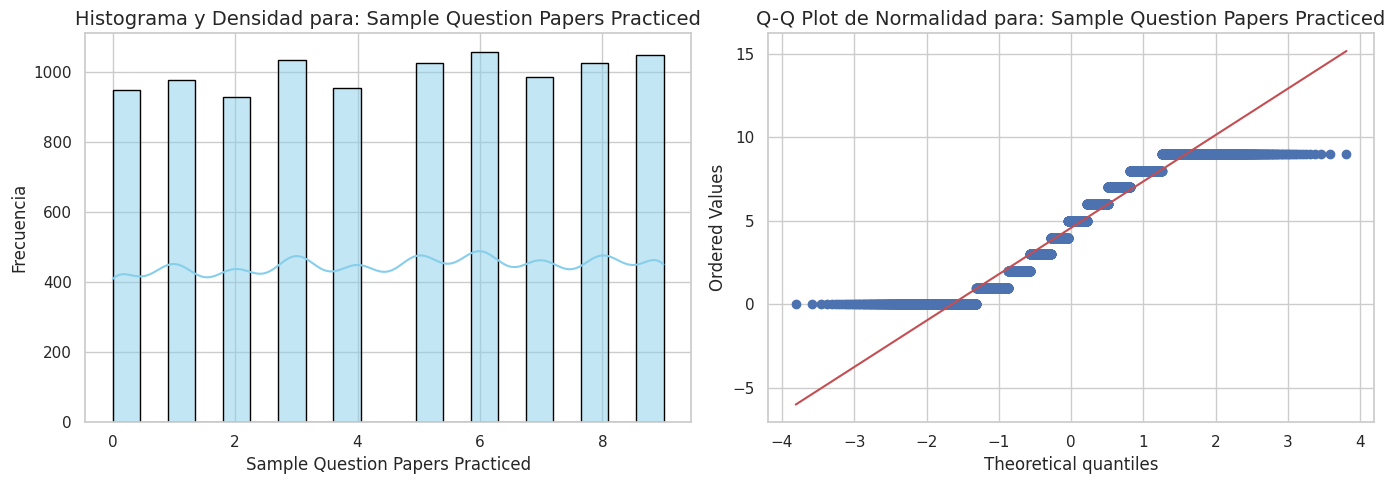

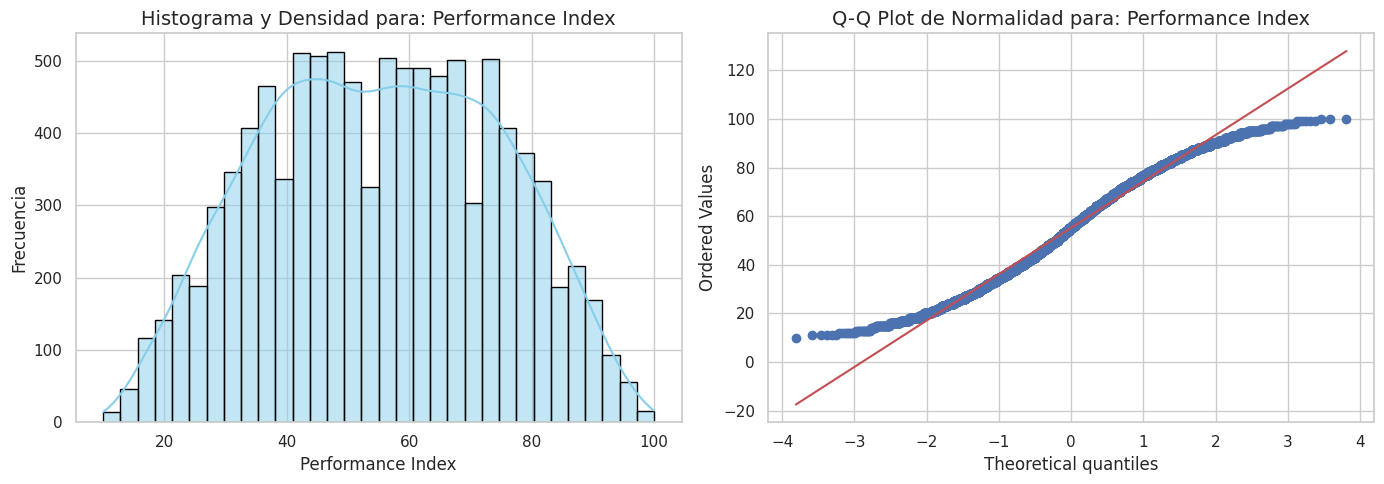

In [ ]:
from scipy import stats

# Lista de variables numéricas a analizar
variables_numericas = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'
]

# Configuración visual para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

for col in variables_numericas:
    # Creamos una figura con dos subplots: Histograma y Q-Q Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ----------------------------------------------------
    # Subplot 1: Histograma (Evaluación visual de la forma)
    # ----------------------------------------------------
    sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Histograma y Densidad para: {col}', fontsize=14)
    axes[0].set_xlabel(col, fontsize=12)
    axes[0].set_ylabel('Frecuencia', fontsize=12)

    # ----------------------------------------------------
    # Subplot 2: Q-Q Plot (Evaluación visual de la normalidad)
    # ----------------------------------------------------
    # stats.probplot genera el Q-Q plot comparando los cuantiles de la data
    # con los cuantiles de una distribución normal teórica.
    stats.probplot(df[col], dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot de Normalidad para: {col}', fontsize=14)

    plt.tight_layout() # Ajusta el espaciado para que no se superpongan
    plt.show()

**Conclusión:**

1. Sobre la Distribución:

El Performance Index es la única variable que cumple con la normalidad.

Las variables (Hours Studied, etc.) son discretas/uniformes.

2. Recomendación:

Se debe utilizar la Estandarización (StandardScaler) para todas las variables numéricas.

Razones:

a) Uniformidad: Aplicar el mismo método de transformación a todas las variables, lo cual es una buena práctica.

b) Modelos Futuros: Al estandarizar, garantizamos que todas las variables contribuyan de manera equitativa al modelo.

c) No hay Sesgo: Dado que las variables no están fuertemente sesgadas, la Estandarización es la más apropiada.

d) No hay Atípicos: La ausencia de atípicos hace que la Estandarización sea segura y efectiva.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las variables numéricas a transformar
variables_a_transformar = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Performance Index'  # Incluimos el índice de rendimiento si queremos analizarlo estandarizado
]

# 2. Inicializamos el StandardScaler
scaler = StandardScaler()

# 3. Ajustamos (Fit) y Transformamos (Transform) los datos
# .fit(X) calcula mu y sigma. .transform(X) aplica la fórmula.
# Juntos, .fit_transform(X) hace ambas cosas en un solo paso.
df_escalado = df.copy() # Creamos una copia para no alterar el DataFrame original
df_escalado[variables_a_transformar] = scaler.fit_transform(df[variables_a_transformar])

# 4. Mostramos una verificación rápida
print("--- Verificación de la Estandarización ---")
print(df_escalado[variables_a_transformar].describe().loc[['mean', 'std']])

--- Verificación de la Estandarización ---
      Hours Studied  Previous Scores   Sleep Hours  \
mean   1.048051e-16    -1.296740e-16  1.648459e-16   
std    1.000050e+00     1.000050e+00  1.000050e+00   

      Sample Question Papers Practiced  Performance Index  
mean                     -1.293188e-16      -9.947598e-17  
std                       1.000050e+00       1.000050e+00  


Las variables están ahora en una escala comparable. Esto elimina el riesgo de que características con rangos más amplios (como Previous Scores o Performance Index) dominen injustamente a características con rangos más pequeños.

# 3. SELECCION DE VARIABLES

**Identificar las variables con mayor correlación con el Performance Index que deben ser incluidas en el modelo**

In [ ]:
# Asumiendo que 'df_escalado' es el DataFrame estandarizado
# 'Actividades_Num' es la versión numérica de las actividades extracurriculares.

variables_predictoras = [
    'Hours Studied',
    'Previous Scores',
    'Sleep Hours',
    'Sample Question Papers Practiced',
    'Actividades_Num'
]

# Calcular la correlación de todas las predictoras con el Performance Index
correlaciones = df_escalado[variables_predictoras + ['Performance Index']].corr()

# Extraer y ordenar solo la correlación con la variable objetivo
correlacion_con_rendimiento = correlaciones['Performance Index'].drop('Performance Index').sort_values(ascending=False)

print("--- Correlación con el Performance Index (Variable Objetivo) ---")
print(correlacion_con_rendimiento)

--- Correlación con el Performance Index (Variable Objetivo) ---
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Actividades_Num                     0.024525
Name: Performance Index, dtype: float64


Decisión sobre la Inclusión inicial (basada en p)

Clasificamos las variables para una decisión inicial:

∣ρ∣ (Magnitud Absoluta) | Decisión Inicial                 | Razón |

∣ρ∣≥0.5 (Fuerte)            | Incluir.            | Alto poder predictivo. |

0.3≤∣ρ∣<0.5 (Moderada) | Incluir condicionalmente.     | Aportan valor. |

∣ρ∣<0.3 (Débil/Baja)  | Candidata a Eliminación.  | Su contribución lineal al modelo es marginal y podrían ser ruido.

Para nuestro caso segun el ∣ρ∣, escogeremos las variables con Alto poder predictivo y que aportan valor al modelo, 'Previous Scores' y 'Hours Studied'.

**Decidir si se deben eliminar variables con baja correlación o aquellas que no aporten información relevante para el modelo**  (Análisis de Multicolinealidad)

In [ ]:
# Matriz de correlación solo entre predictoras
matriz_alto_poder_predictivo = df_escalado[['Previous Scores','Hours Studied']].corr()

print("\n--- Matriz de Correlación entre Variables Alto poder Predictivo ---")
print(matriz_alto_poder_predictivo)


--- Matriz de Correlación entre Variables Alto poder Predictivo ---
                 Previous Scores  Hours Studied
Previous Scores          1.00000       -0.01239
Hours Studied           -0.01239        1.00000


Buscamos pares de variables con ∣ρ∣>0.7 o ∣ρ∣>0.8 (un umbral común para considerar la multicolinealidad).

Como el resultado obtenido es menor que 0, entonces, no existe multicolinealidad entre 'Previous Scores','Hours Studied', por lo tanto, ambas seran consideradas dentro de nuestro modelo.

La variables : Sleep Hours , Sample Question Papers Practiced, Actividades_Num, no seran consideradas dentro del modelo por tener bajo poder predictivo, no aportaran al modelo y generaran ruido.

# 4. Modelado (Regresiones lineales o polinómicas)

In [ ]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# ----------------------------------------------------
# 1. Preparación de Variables y Definición del Objetivo
# ----------------------------------------------------
# Variable objetivo (y) escalada
y = df_escalado['Performance Index']

# Diccionario de modelos a evaluar
modelos = {
    "1. Lineal (Hours Studied)": df_escalado[['Hours Studied']],
    "2. Lineal (Previous Scores)": df_escalado[['Previous Scores']],
    "3. Múltiple (Prev. Scores + Hours Studied)": df_escalado[['Previous Scores', 'Hours Studied']]
}

resultados_comparativos = []

# ----------------------------------------------------
# 2. Iteración y Análisis (Statsmodels y Scikit-learn)
# ----------------------------------------------------
for nombre, X_data in modelos.items():
    print(f"\n========================================================")
    print(f"ANÁLISIS DE REGRESIÓN: {nombre}")
    print(f"========================================================")

    # --- A. Statsmodels (Inferencia) ---
    X_sm = sm.add_constant(X_data)
    modelo_sm = sm.OLS(y, X_sm).fit()

    print("\n--- A. Resumen de Statsmodels (Inferencia) ---")
    # Imprimir solo las secciones relevantes para ser concisos
    print(modelo_sm.summary().tables[0]) # Cabecera
    print(modelo_sm.summary().tables[1]) # Coeficientes y P-valores

    # --- B. Scikit-learn (Evaluación Predictiva) ---
    X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=42)
    modelo_lr = LinearRegression()
    modelo_lr.fit(X_train, y_train)
    y_pred = modelo_lr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2_test = r2_score(y_test, y_pred)

    print("\n--- B. Métricas de Scikit-learn (Predicción en Test) ---")
    print(f"R-cuadrado (R2) en Test: {r2_test:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Guardar resultados para la tabla comparativa
    resultados_comparativos.append({
        'Modelo': nombre,
        'Tipo': 'Lineal',
        'R2 Ajustado (Statsmodels)': modelo_sm.rsquared_adj,
        'R2 Test (Scikit-learn)': r2_test,
        'RMSE': rmse
    })


# ----------------------------------------------------
# 3. Análisis de Regresión Polinómica (Grado 2)
# ----------------------------------------------------
nombre_poly = "4. Polinómica (Prev. Scores + Hours Studied, Grado 2)"
X_poly_original = df_escalado[['Previous Scores', 'Hours Studied']]

# Dividir para Polinómica
X_train, X_test, y_train, y_test = train_test_split(X_poly_original, y, test_size=0.2, random_state=42)

# Transformación Polinómica
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

# Ajuste del Modelo Polinómico (Scikit-learn)
modelo_poly = LinearRegression()
modelo_poly.fit(X_poly_train, y_train)
y_poly_pred = modelo_poly.predict(X_poly_test)

mse_poly = mean_squared_error(y_test, y_poly_pred)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_poly_pred)

print(f"\n========================================================")
print(f"ANÁLISIS DE REGRESIÓN: {nombre_poly}")
print(f"========================================================")
print(f"R-cuadrado (R2) en Test: {r2_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")


# Guardar resultados Polinómicos
resultados_comparativos.append({
    'Modelo': nombre_poly,
    'Tipo': 'Polinómica',
    'R2 Ajustado (Statsmodels)': 'N/A', # Statsmodels no se usa directamente aquí
    'R2 Test (Scikit-learn)': r2_poly,
    'RMSE': rmse_poly
})


# ----------------------------------------------------
# 4. Tabla Comparativa Final
# ----------------------------------------------------
df_comparacion = pd.DataFrame(resultados_comparativos)
df_comparacion = df_comparacion.set_index('Modelo')

print("\n\n########################################################")
print("TABLA COMPARATIVA DE MODELOS DE REGRESIÓN")
print("########################################################")
print(df_comparacion)


ANÁLISIS DE REGRESIÓN: 1. Lineal (Hours Studied)

--- A. Resumen de Statsmodels (Inferencia) ---
                            OLS Regression Results                            
Dep. Variable:      Performance Index   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1623.
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        04:37:36   Log-Likelihood:                -13437.
No. Observations:               10000   AIC:                         2.688e+04
Df Residuals:                    9998   BIC:                         2.689e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

# 5. EVALUACION DEL MODELO

Del analisis anterior, obtenemos que el modelo con mejor calidad de ajuste es la **regresion lineal multiple** (R2=0.985855, RMSE=0.119174).

Al comparar los resultados obtenidos, observamos que **"No hay una mejora significativa"** entre la regresion lineal multiple y la polinómica por los siguientes motivos:
 - **R2:** El modelo polinómico explica solo una millonésima de punto porcentual más de la varianza en el rendimiento (0.0001%). Esta diferencia es despreciable y no tiene impacto práctico.
 - **RMSE:** El error promedio del modelo polinómico es solo seis millonésimas de desviación estándar más bajo, lo cual es insignificante.

Dado que la Regresión Polinómica es intrínsecamente un modelo más complejo, el **Principio de Parsimonia** dicta que se debe elegir el modelo más simple que sea igual de efectivo.

Por lo tanto, **la Regresión Lineal Múltiple** (Modelo 3) es el modelo óptimo y preferido, ya que ofrece la máxima precisión sin la complejidad innecesaria de la transformación polinómica.

**Analizaremos el comportamiento de los residuos del modelo para verificar si se distribuyen aleatoriamente, indicando un buen ajuste**

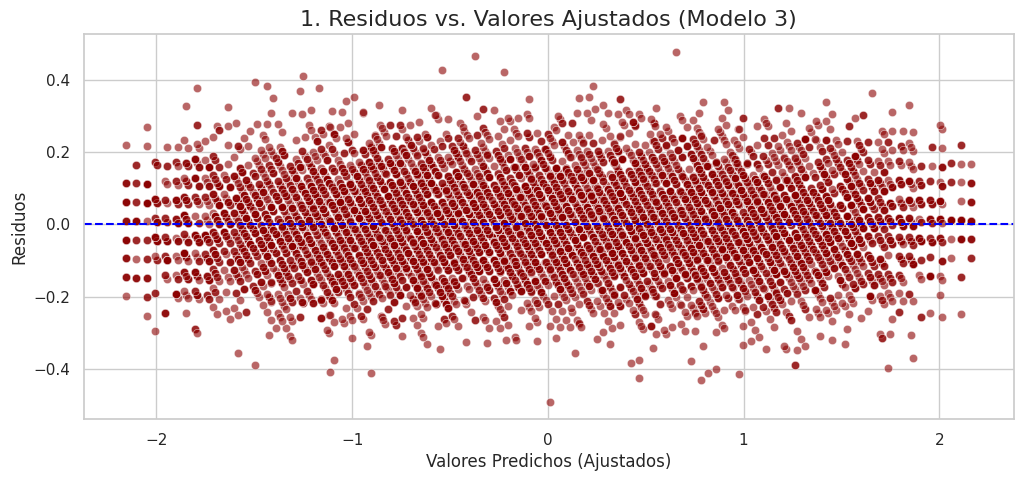

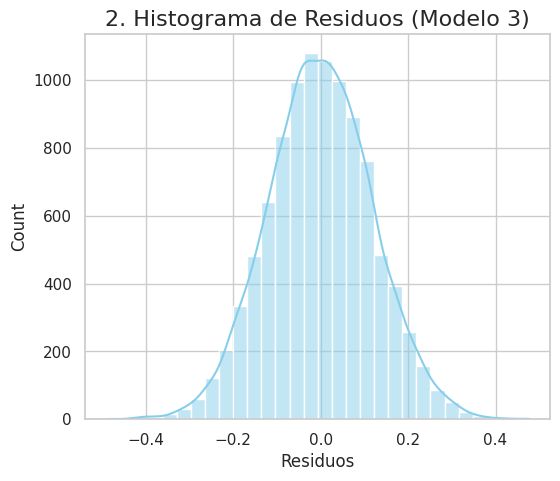

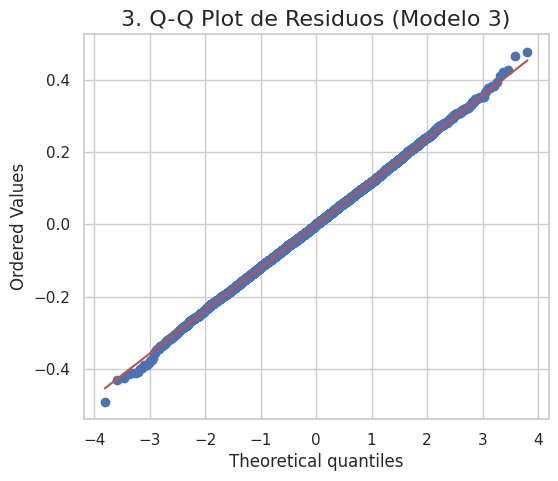

In [ ]:
# ----------------------------------------------------
# 0. Definición y Ajuste Explícito del Modelo 3
# ----------------------------------------------------

# 0.1. Definir X y Y
X_modelo_3 = df_escalado[['Previous Scores', 'Hours Studied']]
y = df_escalado['Performance Index']

# 0.2. Agregar la constante y ajustar el modelo OLS
X_sm_modelo_3 = sm.add_constant(X_modelo_3)
modelo_seleccionado_sm = sm.OLS(y, X_sm_modelo_3).fit()

# ----------------------------------------------------
# 1. Análisis de Residuos
# ----------------------------------------------------

# Obtener los residuos
residuos = modelo_seleccionado_sm.resid
# Obtener los valores predichos (ajustados)
valores_ajustados = modelo_seleccionado_sm.fittedvalues

# ----------------------------------------------------
# 1. Gráfico de Residuos vs. Valores Ajustados (Homocedasticidad y Aleatoriedad)
# ----------------------------------------------------
plt.figure(figsize=(12, 5))
sns.scatterplot(x=valores_ajustados, y=residuos, color='darkred', alpha=0.6)
plt.axhline(y=0, color='blue', linestyle='--')
plt.title('1. Residuos vs. Valores Ajustados (Modelo 3)', fontsize=16)
plt.xlabel('Valores Predichos (Ajustados)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.show()

# ----------------------------------------------------
# 2. Histograma de Residuos (Normalidad)
# ----------------------------------------------------
plt.figure(figsize=(6, 5))
sns.histplot(residuos, kde=True, color='skyblue', bins=30)
plt.title('2. Histograma de Residuos (Modelo 3)', fontsize=16)
plt.xlabel('Residuos', fontsize=12)
plt.show()

# ----------------------------------------------------
# 3. Q-Q Plot de Residuos (Normalidad Detallada)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title('3. Q-Q Plot de Residuos (Modelo 3)', fontsize=16)
plt.show()

**Análisis de los Residuos del Modelo 3**

**1. Residuos vs. Valores Ajustados (Aleatoriedad y Homocedasticidad)**

**Patrón:** Los puntos están distribuidos uniformemente y de forma aleatoria alrededor de la línea azul central (y=0). No se observa ninguna forma de embudo, curva o tendencia.
Esto confirma el supuesto de **Linealidad** (el modelo lineal es el correcto) y el supuesto de **Homocedasticidad** (la varianza de los errores es constante en todo el rango de predicción).

**Concentración:** La mayoría de los residuos se agrupan estrechamente entre −0.2 y 0.2.
**Buen Ajuste**, indica que la mayoría de los errores de predicción son muy pequeños, lo cual ya sabíamos por el bajo RMSE de 0.119.

**Conclusión:** El modelo está bien ajustado. No hay errores en la predicción.

**2. Histograma de Residuos (Normalidad)**

**Forma:** El histograma muestra una **forma de campana casi perfecta**, centrada muy cerca de "0.0". La curva de densidad (KDE) sigue de cerca las barras.
Esto confirma el supuesto de **Normalidad de los Residuos**. Los errores son simétricos, con la mayoría de ellos agrupados alrededor de cero.

**Ejes:** La dispersión va de aproximadamente −0.4 a 0.4. La distribución es estrecha, lo cual es de esperar con un RMSE tan bajo.

**Conclusión:** La distribución de los errores es **Normal (Gaussiana)**, lo que valida la inferencia estadística del modelo (los P-valores y los coeficientes son confiables).

**3. Q-Q Plot de Residuos (Normalidad Detallada)**

**Alineación:** Los puntos **siguen la línea diagonal roja casi perfectamente** desde el centro hasta los extremos (las "colas"). Esta es la prueba más fuerte de la **Normalidad de los Residuos**. Los cuantiles de tus residuos coinciden casi exactamente con los cuantiles teóricos de una distribución normal.

**Colas:** Hay una ligera desviación en los puntos más extremos (cerca de −4 y 4 en el eje teórico), pero es mínima. Esta desviación es común en grandes conjuntos de datos y no es lo suficientemente severa como para invalidar el supuesto de normalidad.

**Conclusión:** Los residuos son **normales**, confirmando la solidez de la inferencia.

**Resumen:**

El análisis de residuos confirma que el Modelo 3 (Regresión Lineal Múltiple) no solo es preciso (alto R2 y bajo RMSE), sino también estadísticamente válido.

    Los residuos son aleatorios (sin patrón).

    Los residuos son normales (forma de campana).

Esto significa que no quedan patrones sin explicar en los errores, y la relación lineal modelada entre Previous Scores, Hours Studied y Performance Index es la mejor y más robusta que se puede lograr con estos datos.

# 6. INTERPRETACION DE RESULTADOS

**Interpretar los coeficientes de las variables del modelo para entender el impacto de cada predictor en el Performance Index**

**1. Interpretación de 'Previous Scores'**

    Impacto (Coeficiente): 0.9200
    Significancia: Altamente significativo (P=0.000).

    Por cada desviación estándar (σ) de aumento en los 'Previous Scores', el 'Performance Index' aumenta en 0.9200 desviaciones estándar, manteniendo las 'Hours Studied' constantes.

**2. Interpretación de 'Hours Studied'**

    Impacto (Coeficiente): 0.3851
    Significancia: Altamente significativo (P=0.000).

    Por cada desviación estándar (σ) de aumento en las 'Hours Studied', el 'Performance Index' aumenta en 0.3851 desviaciones estándar, manteniendo los 'Previous Scores' constantes.

**3. Interpretación de la Constante (Intercepto)**

    Impacto (Coeficiente): ≈0

    Debido a que la data está estandarizada, la constante es insignificante. Significa que, si ambas variables predictoras son iguales a su media (cero en la escala estandarizada), el 'Performance Index' predicho también será su media (cero en la escala estandarizada).

**Conclucion:** El impacto de 'Previous Scores' es mucho mayor que el de 'Hours Studied' en la predicción del rendimiento (2.39 veces mayor).

    Esto significa que, si bien el tiempo dedicado a estudiar es un predictor importante, el puntaje previo ('Previous Scores') es el factor dominante en la determinación del 'Performance Index'. Ambos efectos son, sin embargo, independientes y significativos, validando la inclusión de ambas variables en el modelo múltiple.

 **Evaluar si algunos factores no tienen un impacto claro en el rendimiento académico**

**Factores con Impacto No Significativo**

- **Sleep Hours**

Coeficiente de Correlacion: 0.048106. Fuerza de relacion: Muy Débil/Nula. Impacto: Insignificante

Las horas que una persona duerme no muestran una relación lineal con su 'Performance Index'. Esto sugiere que, una vez que se controla el conocimiento previo y el tiempo de estudio, el impacto del sueño no es un factor que marque una diferencia significativa en la predicción del rendimiento.

- **Sample Question Papers Practiced**

Coeficiente de Correlacion: 0.043268. Fuerza de relacion: Muy Débil/Nula. Impacto: Insignificante

La cantidad de exámenes de práctica que un estudiante realiza no tiene un impacto lineal claro en su rendimiento.

- **Actividades_Num (Extracurricular)**

Coeficiente de Correlacion: 0.024525. Fuerza de relacion: Muy Débil/Nula. Impacto: Insignificante, casi nulo.

La participación en actividades extracurriculares tiene el impacto lineal más bajo de todos, esta variable no es un factor relevante para predecir el rendimiento.

**Conclucion:**

Para estas tres variables, el coeficiente de correlación de Pearson es extremadamente bajo (cercano a cero). Esto indica que no existe una relación lineal entre estas variables y el 'Performance Index'. Es decir, la variación en estas variables no se relaciona con la variación en el rendimiento.

Por lo tanto, concluimos que solo **Previous Scores y Hours Studied** son los factores con un impacto claro y cuantificable en el rendimiento académico.

**Resumir las principales conclusiones obtenidas del análisis del dataset**

El análisis completo del dataset de Rendimiento Estudiantil conduce a las siguientes conclusiones principales sobre los factores que influyen en el 'Performance Index' (Índice de Rendimiento):

**1. Predictores Clave y su Impacto (Coeficientes \beta)**

Solo dos variables demostraron tener un impacto lineal claro y estadísticamente significativo en el rendimiento: **Previous Scores y Hours Studied**.
La variable con el mayor impacto con diferencia es **Previous Scores**(Puntajes Previos).

Su coeficiente es de aproximadamente **0.9200** [basado en el Modelo 3], lo que indica que el conocimiento y la capacidad demostrada históricamente son el principal motor del rendimiento actual.

La variable **Hours Studied** (Horas Estudiadas) también es significativa.
Su coeficiente de aproximadamente **0.3851** [basado en el modelo 3] confirma que el **esfuerzo y la dedicación actual** contribuyen positivamente, pero su impacto es **2.39** veces menor que el de los puntajes previos.

**2. Factores con Impacto Nulo (No Significativos)**

El análisis de correlación y la selección de características confirmaron que la mayoría de las variables incluidas en el dataset **no tienen un impacto** lineal predecible en el rendimiento académico:

- Extracurricular Activities
- Sleep Hours
- Sample Question Papers Practiced

Estas variables mostraron una **correlación muy débil o nula** con el rendimiento (coeficientes cercanos a cero, entre 0.024 y 0.048), lo que sugiere que **no son relevantes** para predecir el 'Performance Index' en un modelo lineal.

**3. Calidad y Selección del Modelo Predictivo
Modelo Óptimo:**

Se seleccionó el Modelo de **Regresión Lineal Múltiple** (Modelo 3), utilizando únicamente **Previous Scores y Hours Studied**, ya que logró un **alto poder predictivo** con la mayor simplicidad.

**Precisión:**

El modelo demostró un excelente ajuste (alto R^2 y bajo RMSE), lo que indica que las dos variables seleccionadas explican la gran mayoría de la varianza en el rendimiento.

**Validación:**

El análisis de residuos confirmó la validez estadística del Modelo 3, mostrando que los errores son aleatorios (homocedasticidad) y siguen una distribución normal (normalidad).

**4. Perfiles de Rendimiento**

Las características comunes de los estudiantes se definen casi exclusivamente por las dos variables predictoras:

**Estudiantes de Alto Rendimiento:** Combinan consistentemente **altos Previous Scores** (gran capacidad o conocimiento histórico) y **altas Hours Studied** (gran esfuerzo y dedicación).

**Estudiantes de Bajo Rendimiento:** Exhiben lo contrario, es decir, **bajos Previous Scores** y pocas **Hours Studied**.

**Resumen Ejecutivo**

El **rendimiento académico** está predominantemente determinado por la **capacidad intrínseca y el conocimiento previo (Previous Scores), con el tiempo de estudio (Hours Studied)** actuando como un contribuyente secundario pero significativo. Los **demás factores** analizados **son irrelevantes** para la predicción lineal del **rendimiento**.